In [1]:
# 1.그래프 구현(기본)
# 2.nan 값을 다른 값으로 채우는 방법
# 3.델타와 세타
# 4.비표준 결측값을 NaN으로 변환 후 결측치 처리
# 5.히스토그램 구간 정하기

In [2]:
# 1.그래프 구현(기본)
# seaborn에서 지원하는 그래프들중에서도 수업중에 사용하거나, 핵심 그래프들에 대해서 알아보기.

# 그래프에 표현되는 데이터들의 유형에 대해서 알아보자.
# 1️⃣ 데이터 유형
# 1. 수치형(Numerical, Quantitative)
# 정의: 숫자로 표현되는 데이터. 크기나 연산이 가능.
# 예시: 나이, 월급, 키, 체중, 총매출
# 세부 유형:
# 연속형(Continuous): 실수값 가능 (예: 170.5cm, 23.7도)
# 이산형(Discrete): 정수값만 가능 (예: 학생 수, 방문 횟수) -> 세부유형 부분은 그런게 있구나 정도로
# 분석/시각화 예: histplot, kdeplot, scatterplot, lineplot

# 2. 범주형(Categorical, Qualitative)
# 정의: 몇 가지 범주로 나뉘는 데이터. 연산보다 그룹 구분이 중요.
# 예시: 성별(남/여), 결혼 여부(Yes/No), 요일(Mon/Tue...), 제품 종류
# 세부 유형:
# 명목형(Nominal): 순서 의미 없음 (예: 색깔, 국가)
# 순서형(Ordinal): 순서 의미 있음 (예: 만족도 1~5, 학년)
# 분석/시각화 예: countplot, barplot, boxplot, violinplot

# 2️⃣ 데이터 관계 형태
# 1. 선형적 관계(Linear)
# 정의: 두 변수 간 관계가 직선으로 나타나는 경우.
# 특징:
# 변화율이 일정
# 상관관계 분석 가능 (Pearson 등)
# 예시: 공부시간 ↔ 시험 점수, 광고비 ↔ 매출
# 분석/시각화: scatterplot + regplot, corr(), lineplot

# 2. 비선형적 관계(Non-linear)
# 정의: 두 변수 간 관계가 곡선 형태 또는 복잡한 형태.
# 특징:
# 변화율 일정하지 않음
# 선형 상관계수로 관계를 제대로 설명하기 어려움
# 예시: 온도 ↔ 아이스크림 판매량 (너무 낮으면 판매 적음, 높으면 많음, 너무 높으면 다시 감소)
# 분석/시각화: scatterplot, kdeplot, 회귀 모델은 비선형 회귀 또는 다항회귀 사용

# 시각화 라이브러리들과 각 기능
# https://chatgpt.com/share/68dcf5c2-d430-8012-be1a-dcbfe8219226
# 그래프는 내용이 많으니, 간추리자면 먼저 seaborn과 plot, subplots 숙지해보기

In [3]:
# 데이터 특성에 따라, 그리고 자주 나오는 그래프 정리 (seaborn)
# 1 ] 수치형 : 나이, 키, 월급 -> histplot, kdeplot, scatterplot
# 2 ] 범주형 : 성별, 요일, 등급	-> countplot, barplot, boxplot

# 선형적 관계 : 공부시간 ↔ 점수	-> scatterplot + regplot, corr()
# 비선형적 관계 : 온도 ↔ 판매량	-> scatterplot, 곡선회귀, kdeplot

# 내용이 많아서 필요한것만 간략하게 정리합니다.

# subplots, ax 위치지정 기능 제공 여부
# relplot, catplot 같은 "figure-level" 함수는 ax를 직접 받지 않는다.
# -> 그외 seaborn 그래프는 subplots에 ax 지정이 가능하다.

In [4]:
# 예제용 데이터 가져오기
import pandas as pd
import seaborn as sns
url ='https://raw.githubusercontent.com/pia222sk20/python_src/refs/heads/main/data/titanic.csv'
titanic = pd.read_csv(url)
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
# 1 ]
# histplot, kdeplot, scatterplot : 수치형 데이터
# https://chatgpt.com/share/68dcf681-3d64-8012-9c9e-79961fc730df 

<Axes: xlabel='Pclass', ylabel='Count'>

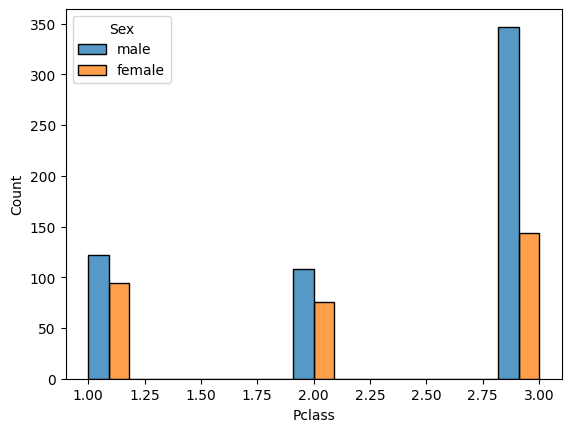

In [6]:
# 1 ) sns.histplot()
#수치형 데이터의 분포를 시각화
# 데이터를 **구간(bins)**으로 나누어 각 구간의 빈도수를 막대그래프로 표현
# 데이터가 얼마나 특정 값에 몰려 있는지 확인 가능

# sns.histplot(data=df, x='age', bins=10, hue= ,kde=False)
# data : 데이터프레임 지정
# x	: 히스토그램으로 나타낼 데이터.(주로) 수치형 변수
# 보통 sns.histplot()은 기본적으로 x축에 데이터를 두고, y축에는 **빈도(횟수)**가 자동으로 표시돼요.
# 여기서 x 대신 y를 지정하면, 가로방향 히스토그램을 그릴 수 있습니다.
# y : 히스토그램으로 나타낼 데이터.수치형
# x나 y 중에 하나에 데이터를 넣으면 다른쪽은 저절로 빈도값이 들어간다.
# -> x,y중에 하나의 축을 정하고 어느 데이터를 넣을지 지정하면된다.

# bins : 구간 수 지정 (디폴트: 자동)
# hue : 범주형 변수를 기준으로 색 구분 ^
# multiple : 겹치는 막대 표시 방식(stack, dodge, fill) ^

# kde : 히스토그램 위에 매끄러운 분포 곡선 여부

# 데이터 특성을 고려해서, 그래프 생성 예제 :
sns.histplot(data=titanic,x='Pclass', hue='Sex',multiple="dodge",kde=False)

<Axes: xlabel='Sex', ylabel='Count'>

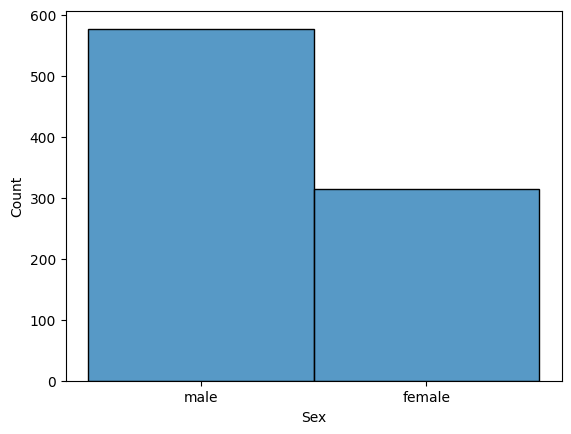

In [7]:
# 범주형 데이터를 넣으면, 사실상 countplot처럼 동작한다.
sns.histplot(data=titanic, x='Sex')

<Axes: xlabel='Sex', ylabel='count'>

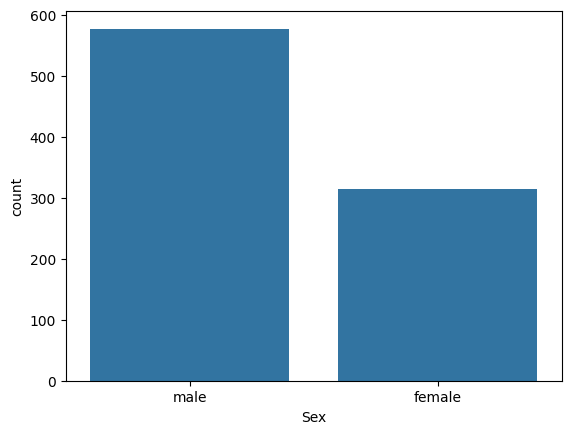

In [8]:
sns.countplot(data=titanic, x='Sex')
# 그럼 countplot에서 범주형데이터가 아닌 수치형데이터를 넣으면 어떻게 되는지,
# sns.countplot()은 원래 범주형 데이터 전용이라서, 기본적으로는 카테고리별 빈도를 세는 함수예요.
# 그런데 수치형 데이터를 넣으면 → 숫자를 범주처럼 취급해서 동작합니다.
# 나이 항목 하나하나에 그래프가 생긴다. (시각적으로 보기 안좋다는 말)

<Axes: xlabel='Age', ylabel='Density'>

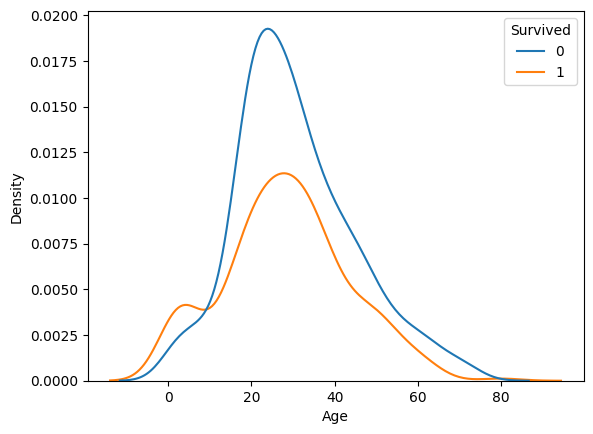

In [9]:
# 2 )s ns.kdeplot()
# 수치형 데이터의 연속적인 분포를 부드러운 곡선으로 표현
# 히스토그램의 연속적 버전으로 이해하면 쉬움
# 데이터의 밀집도를 시각화 가능

# sns.kdeplot(data=df, x='age', fill=True)
# data : 데이터프레임 지정
# x : 곡선으로 나타낼 데이터.수치형 변수
# y	: 2차원 분포 가능 (x와 y 둘 다 지정) ^
# hue : 범주별 밀도 곡선

# y, hue 중 하나만 지정해야된다?
# sns.kdeplot()에서 **x + y + hue**를 지정하면,
# → x, y 두 변수로 2차원 분포를 그리고,
# → hue에 따라 범주별로 색상을 나눠 여러 2D KDE를 한 그래프에 표시할 수 있습니다.

# multipl : 범주형 곡선을 겹치는 방식(stack, dodge, fill)

# fill : True면 곡선 아래를 채움
# bw_adjust : 곡선의 부드러움 조정 (작을수록 더 세밀)
sns.kdeplot(data=titanic,x='Age',hue='Survived')

<Axes: xlabel='Age', ylabel='Fare'>

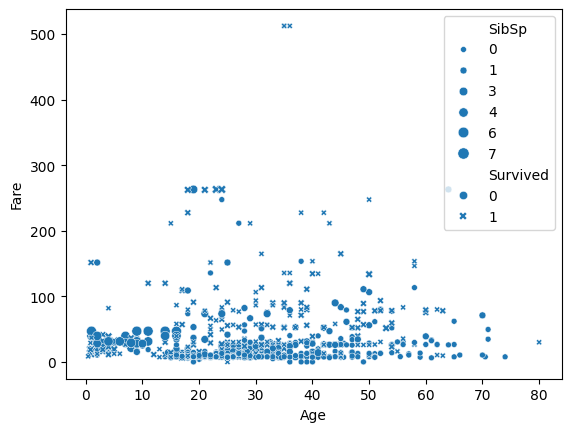

In [10]:
# 3 ) sns.scatterplot()
# 두 수치형 변수 간 관계를 점으로 표현
# 변수 간 선형/비선형 관계, 패턴 확인 가능
# 범주형 변수에 따라 색, 모양, 크기 등을 달리 표현 가능

# sns.kdeplot(data=df, x='age', fill=True)
# data : 데이터프레임 지정
# x, y : 산점도로 나타낼 데이터.수치형 변수

# hue : 색상 구분.범주형 변수
# style : 점 모양 구분.범주형 변수
# size : 점 크기 추가정보 표현.범주형 변수

# alpha : 점 투명도 조절 (겹치는 데이터 확인 용이).

sns.scatterplot(data=titanic,x='Age',y='Fare',style='Survived',size='SibSp')

In [11]:
# 2 ]
# countplot, barplot, boxplot : 범주형 데이터
# https://chatgpt.com/share/68dcf681-3d64-8012-9c9e-79961fc730df

<Axes: xlabel='Pclass', ylabel='count'>

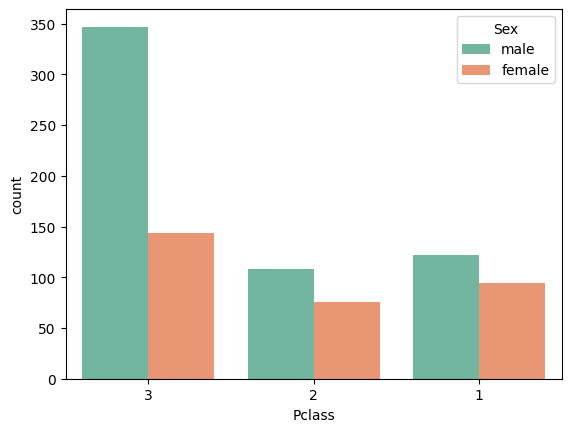

In [12]:
# 1 )sns.countplot()
# 용도: 범주형 변수의 값별 **빈도(frequency)**를 막대그래프 형태로 보여줌.
# 결과: 각 범주가 데이터에 몇 번 나타나는지 시각적으로 확인 가능.

# sns.countplot(data=df, x='Gender', hue='Churn', palette='Set2')
# data	DataFrame 지정
# x	: x축에 표현할 범주형 변수
# y	: y축에 표현할 범주형 변수 (x와 y 중 하나만 선택 가능)
# hue :범주형 변수로 그룹화하여 색상을 다르게 표시

# palette : 막대 색상 지정
# order : order는 막대그래프에 표시될 범주의 순서를 직접 지정할 때 사용합니다.
    # 기본 동작: Seaborn은 데이터에 등장한 순서나 알파벳 순서로 막대를 정렬합니다.
    # sns.countplot(data=df, x='Gender', order=['Female','Male'])
    # 결과: x축 막대가 Female → Male 순서로 표시됨.
    # hue가 있을 때도 x축 범주 순서만 지정됨.
        # order는 항상 x축 범주 기준이지, hue 그룹 내부 순서는 제어하지 못해요
        # hue는 어떻게 지정할수있는데?
            #palette='Set2' → 색상 지정
            # hue_order=['No','Yes'] → hue 범주의 순서 지정 가능
            # sns.countplot(data=df, x='Gender', hue='Churn', palette='Set2', hue_order=['No','Yes'])
            # x축: Gender 순서 자동
            # hue: No → Yes 순서로 색상 표시

# x와 y중 하나에만 기재해야한다.
# sns.countplot(data=titanic,x='Sex',y='Pclass')
# TypeError: Cannot pass values for both `x` and `y`.

sns.countplot(data=titanic,x='Pclass',hue='Sex',palette='Set2',order=[3,2,1],hue_order=['male','female'])

In [13]:
import numpy as np

C:\Users\Playdata2\AppData\Local\Temp\ipykernel_16448\2092826824.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(


<Axes: xlabel='Pclass', ylabel='Survived'>

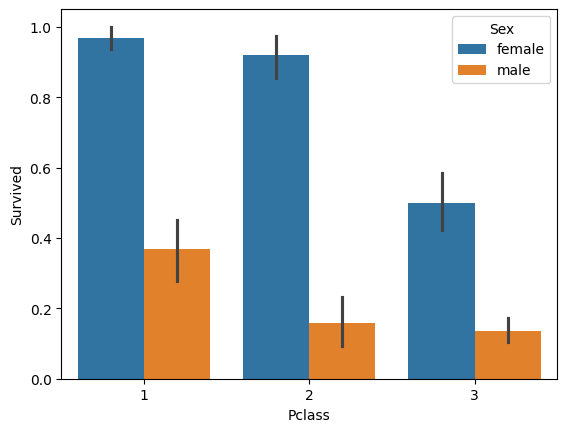

In [ ]:
# 2 )sns.barplot()
# 범주형 변수와 수치형 변수 간의 관계를 시각화할 때 사용.
# 평균값이나 합계 같은 통계치를 막대 그래프로 표시 가능.

# sns.barplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn')
# x 또는 y	범주형 변수
# hue : 다른 범주형 변수로 그룹화 가능
# estimator : estimator는 "범주별 데이터를 어떻게 집계할지"를 결정하는 역할로 : y값을 요약하는 함수
    # 어떻게 요약 할지 설정
    # 평균을 보고 싶으면 np.mean
    # 합계를 보고 싶으면 np.sum
    # 개수(빈도)를 보고 싶으면 len

    # x와 hue 자체에는 그런 요약 조건을 직접 걸 수 없어요.
    # 만약 특정 x값이나 hue값만 보고 싶으면, 데이터 자체를 필터링해야 합니다.

# ci : ci는 막대 높이의 신뢰구간을 표시하는 옵션
    # 신뢰구간 표시 여부 (기본 95%)
    # 95% 신뢰구간 설정
    # sns.barplot(data=df, x='범주컬럼', y='수치컬럼', estimator=np.mean, ci=95)
    # 신뢰구간 제거 설정
    # sns.barplot(data=df, x='범주컬럼', y='수치컬럼', estimator=np.mean, ci=None)

# order	범주 순서 지정 가능
# palette	색상 팔레트 지정 가능

sns.barplot(
    data=titanic,
    x='Pclass',          # 생존 여부
    y='Survived',        # 생존 평균을 막대 높이로 사용
    hue='Sex',           # 성별로 나누기
    estimator=np.mean,   # 평균값 계산
    ci=95                # 95% 신뢰구간 표시
)

<Axes: xlabel='Survived', ylabel='Age'>

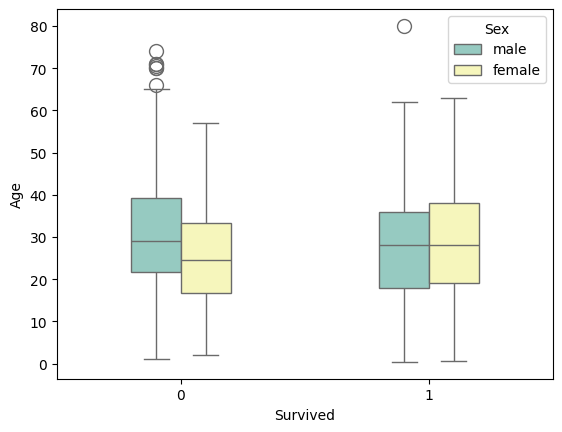

In [31]:
# 3 )sns.boxplot()
# 수치형 데이터의 **분포, 중앙값, 사분위수, 이상치(outlier)**를 시각화.
# 범주형 변수별로 비교할 때 사용.
# 표현되는 박스 범위가 25%~75% 사이이다.

# x 또는 y : 범주형 변수
# hue : 다른 범주형 변수로 그룹화 가능

# width : 박스 너비 조절
    # width = 0 ~ 1 사이 값
    # 1이면 박스가 막대 폭만큼 꽉 찬 형태
    # 0.5면 박스 폭이 절반
    # 0.2처럼 작게 하면 박스 폭이 좁음
# palette : 색상 팔레트 지정 가능
# showfliers : 이상치 표시 여부 (기본 True)
    # fliersize 표시하는 점크기 조절
sns.boxplot(data=titanic,x='Survived',y='Age',hue='Sex',width=0.4,palette='Set3',showfliers=True,fliersize=10)